In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE

In [2]:
#load data (model)
res_savename_ext = "filter_post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v231225"

extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))
extracted_df = gpd.read_parquet(DATA_OUT_PROC / (res_savename_ext+".parquet"))
#load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_all_v111025"
labelled_df = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))


In [9]:
#reformat output
labelled_df = format_output(labelled_df)
#extracted_df = format_output(extracted_df)
#DEF_CRS_EPSG = "EPSG:4326"
#labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)


In [18]:
labelled_df.quanti.value_counts()

quanti
quanti    361
quali     169
Name: count, dtype: int64

In [4]:
flag_cols = [label for label in extracted_df.columns if "flag_" in label or "valid_errors_" in label]

In [5]:
flag_cols

['valid_errors_impactValue',
 'valid_errors_loc',
 'valid_errors_dates',
 'valid_errors_haz',
 'flag_value_not_in_text',
 'flag_impactSubtype_reclass',
 'flag_hazards_reclass',
 'flag_remove_number_unit',
 'flag_SI_unit_standardization',
 'flag_non-SI_unit_standardization',
 'flag_unit_processing_error',
 'flag_unit_nonstd',
 'flag_reclass_subtype_from_unit',
 'flag_pop_cntry',
 'flag_value_no_unit',
 'flag_partial_unit',
 'flag_geocoding_country',
 'flag_geocoding_osm']

In [6]:
extracted_df.columns

Index(['appealCode', 'reportDate', 'reportLink', 'disasterType_IFRC',
       'impactSubtype', 'impactValue', 'impactValueMin', 'impactValueMax',
       'impactValuePrecision', 'impactUnit', 'startYear', 'startMonth',
       'startDay', 'endYear', 'endMonth', 'endDay', 'hazards', 'location',
       'geometry', 'locationPolygon', 'locationLowestAdmin', 'country_iso3',
       'sourceExcerpts', 'valid_errors_impactValue', 'valid_errors_loc',
       'valid_errors_dates', 'valid_errors_haz', 'flag_value_not_in_text',
       'flag_impactSubtype_reclass', 'flag_hazards_reclass',
       'flag_remove_number_unit', 'flag_SI_unit_standardization',
       'flag_non-SI_unit_standardization', 'flag_unit_processing_error',
       'flag_unit_nonstd', 'flag_reclass_subtype_from_unit', 'flag_pop_cntry',
       'flag_value_no_unit', 'flag_partial_unit', 'flag_geocoding_country',
       'flag_geocoding_osm', 'continent'],
      dtype='object')

In [16]:

#extracted_df["impactUnit"] = extracted_df["impactUnit"].replace({"nan of null": "null"})
extracted_df["impactUnit"].value_counts()

impactUnit
null                                            5557
people                                          3001
homes                                            694
families                                         277
EUR                                              243
                                                ... 
% of the public lighting network                   1
% of the drinking water distribution network       1
km**2 of pasture                                   1
villages and communes                              1
metric kg                                          1
Name: count, Length: 183, dtype: int64

In [8]:
extracted_df[extracted_df["flag_geocoding_country"]==True]["location"].value_counts()

location
[Kinshasa]                                                                              26
[Odisha]                                                                                25
[West Bengal]                                                                           12
[Sistan and Baluchestan province]                                                       10
[Barbuda]                                                                                9
                                                                                        ..
[]                                                                                       1
[Karlovac County, Petrinja, Sisak-Moslavina County, Zagreb County]                       1
[]                                                                                       1
[state roads, bridges and structures]                                                    1
[Blantyre, Chikwawa, Chinseu, Chiradzuru District, Mulanje, Nsanje, Phalombe, Zom

In [34]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Residential Buildings                            1163
Affected People                                   940
Economy and Livelihood                            853
Human Health and Wellbeing                        706
Access to Water, Sanitation, and Hygiene          673
Access to Food                                    668
Access to Healthcare                              584
Displaced People                                  543
Crop Production and Forestry                      533
Water Quality and Availability                    504
Water, Sanitation, and Hygiene Infrastructure     438
Human Deaths                                      426
Access to Education                               420
Road Infrastructure                               382
Homeless People                                   371
Mobility and Access to Transport                  299
Injured People                                    298
Education Infrastructure                          296
Affected Lives

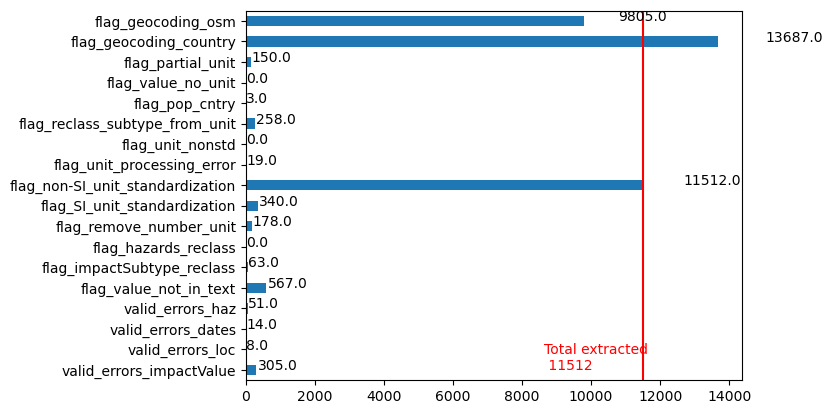

In [20]:
extracted_df["flag_value_not_in_text"] = extracted_df["flag_value_not_in_text"].fillna(0).astype(np.float64)
ax = extracted_df[flag_cols].sum().plot(kind="barh")
ax.axvline(len(extracted_df), color="red")
ax.text(len(extracted_df)*0.75, 0, f"Total extracted\n {len(extracted_df)}", color="red")
for i, v in enumerate(extracted_df[flag_cols].sum()):
    ax.text(v*1.1, i, f"{v}", color="black")
#extracted_df[["appealCode"]+ flag_cols].plot(kind="barh")

In [33]:
extracted_df[extracted_df.appealCode=="MDRSD034"][["location", "locationPolygon", "country_iso3", "flag_geocoding_osm", "flag_geocoding_country"]]

,location,locationPolygon,country_iso3,flag_geocoding_osm,flag_geocoding_country
9022,"[Central Darfur, East Darfur, Kassala, North D...","[Blue Nile, Central Darfur, East Darfur, Madei...","[EGY, SDN]",1.0,0.0
9023,"[Gedaref, Kassala]","[Madeinat Al Gedaref, Madeinat Kassala, Reifi ...",[SDN],1.0,0.0
9024,"[Central Darfur, East Darfur, Kassala, North D...","[Blue Nile, Central Darfur, East Darfur, Madei...","[EGY, SDN]",1.0,0.0
9025,"[Abu Hamad, Abu Sara, Atbara, Gederef, Gold lo...","[Abu Hamad, Agig, Blue Nile, Blue Nile, Easter...","[EGY, FJI, GHA, LKA, SDN, SLE, ZMB]",2.0,2.0
9026,[],[Sudan],[SDN],0.0,1.0
9027,"[Blue Nile, Gadarief, Gazira, Khartoum, North ...","[Blue Nile, Blue Nile, Eastern, Khartoum, Khar...","[EGY, FJI, GHA, LKA, SDN, SLE, ZMB]",1.0,1.0
9028,"[Central Darfur, East Darfur, Gedaref, Kassala...","[Blue Nile, Central Darfur, East Darfur, Madei...",[SDN],2.0,0.0
9029,"[Aqaba, Atbara-Abu Hamad Road, Dongola-Halfa R...","[Agig, Blue Nile, Northern, Port Sudan, Red Se...",[SDN],1.0,4.0
9030,"[Aqaba, Egypt, Jebeit, Port Sudan, Sudan, Tokar]","[Agig, Blue Nile, Egypt, Port Sudan, River Nil...","[EGY, SDN]",1.0,3.0
9031,[Arba’at Dam],[Sudan],[SDN],0.0,1.0


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_99603/3303138969.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_flags)  # tab20 has 20 distinct colors


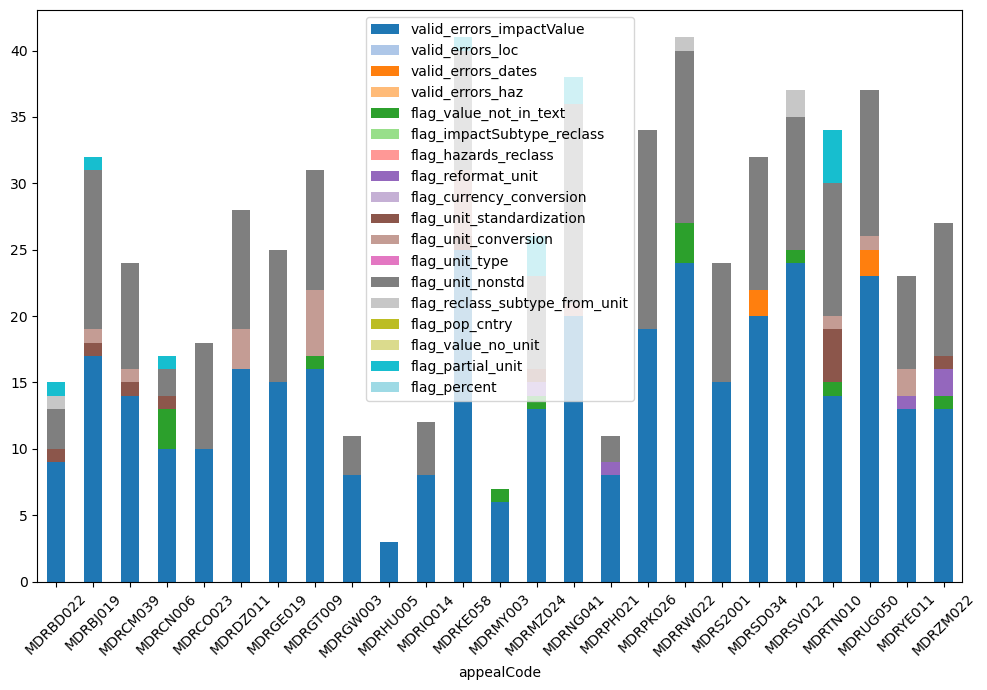

In [23]:
from fileinput import filename
import matplotlib.cm as cm
# Number of unique flag columns
num_flags = len(flag_cols)

# Generate N unique colors from a colormap (e.g., 'tab20', 'viridis', 'nipy_spectral', etc.)
cmap = cm.get_cmap('tab20', num_flags)  # tab20 has 20 distinct colors
colors = [cmap(i) for i in range(num_flags)]

# Make the plot
fig, ax = plt.subplots(1,1, figsize=(10, 7))
extracted_df.groupby("appealCode")[flag_cols].sum().plot(
    kind="bar",
    ax=ax,
    rot=45,
    stacked=True,
    color=colors  # assign unique colors
)

plt.tight_layout()
fig.savefig(DATA_FIGURE / f"flags_{res_savename_ext}.png", bbox_inches="tight", dpi=300)

In [45]:
extracted_df.groupby("appealCode")[flag_cols].sum()

,flag_value_not_in_text,flag_impactSubtype_reclass,flag_hazards_reclass,flag_reformat_unit,flag_currency_conversion,flag_unit_standardization,flag_unit_conversion,flag_unit_type,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent
appealCode,,,,,,,,,,,,,,
MDRBD022,0,0,0,0,0,1,1,0,7,1,0,0,0,0
MDRBJ019,0,0,0,0,0,2,0,0,10,0,0,0,2,0
MDRCM039,0,0,0,0,0,1,0,0,8,0,0,0,0,0
MDRCN006,0,0,0,0,0,1,0,0,1,0,0,0,1,0
MDRCO023,0,0,0,0,0,0,0,0,10,0,0,0,0,0
MDRDZ011,0,0,0,0,0,0,3,0,11,0,0,0,0,0
MDRGE019,0,0,0,0,0,0,0,0,13,0,0,0,0,0
MDRGT009,0,0,0,0,0,0,5,0,3,0,0,0,1,0
MDRGW003,0,0,0,0,0,0,1,0,1,0,0,0,0,0


In [46]:
extracted_df[extracted_df["appealCode"] == "MDRSD034"][["hazards", "flag_hazards_reclass"]]

,hazards,flag_hazards_reclass
24,"[Flood, Epidemic, Conflict]",False
25,"[Flood, Epidemic]",False
26,[Flood],False
27,"[Flood, Epidemic, Conflict]",False
28,"[Flood, Epidemic, Conflict]",False
29,"[Flood, Epidemic]",False
30,"[Flood, Conflict, Epidemic]",False
31,[Flood],False
32,"[Conflict, Flood, Epidemic]",False
33,[Flood],False
